
=== Calibrating rs ===
[LEFT]  RMS: 0.1153
K_L:
[[377.19169852   0.         326.16614698]
 [  0.         389.81912167 284.16777144]
 [  0.           0.           1.        ]]
Dist_L:
[ 0.05943477 -0.15028189  0.0298818  -0.00139234  0.12551665]
[RIGHT] RMS: 0.2025
K_R:
[[380.10110915   0.         322.8867908 ]
 [  0.         386.90844832 263.01189298]
 [  0.           0.           1.        ]]
Dist_R:
[ 0.00369214  0.04456152  0.01604765  0.0046766  -0.05851558]


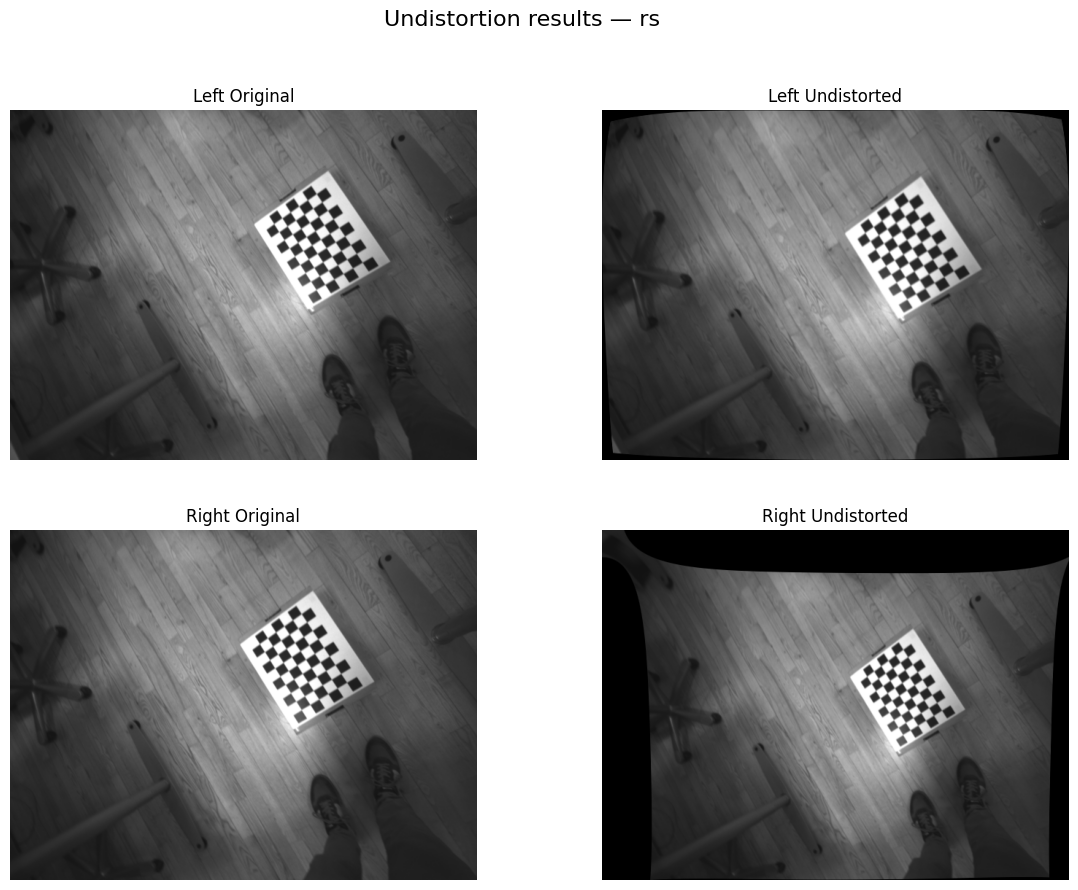


=== Calibrating mynteye ===
[LEFT]  RMS: 0.7516
K_L:
[[1.04209414e+03 0.00000000e+00 6.01590212e+02]
 [0.00000000e+00 9.97452428e+02 3.69222210e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
Dist_L:
[-0.56522481  1.85149555  0.01117473 -0.03906207 -3.08643437]
[RIGHT] RMS: 0.5785
K_R:
[[657.5141821    0.         657.93350656]
 [  0.         657.16391568 360.03463291]
 [  0.           0.           1.        ]]
Dist_R:
[-0.33418115  0.24124251  0.00243655 -0.00118232 -0.16111759]


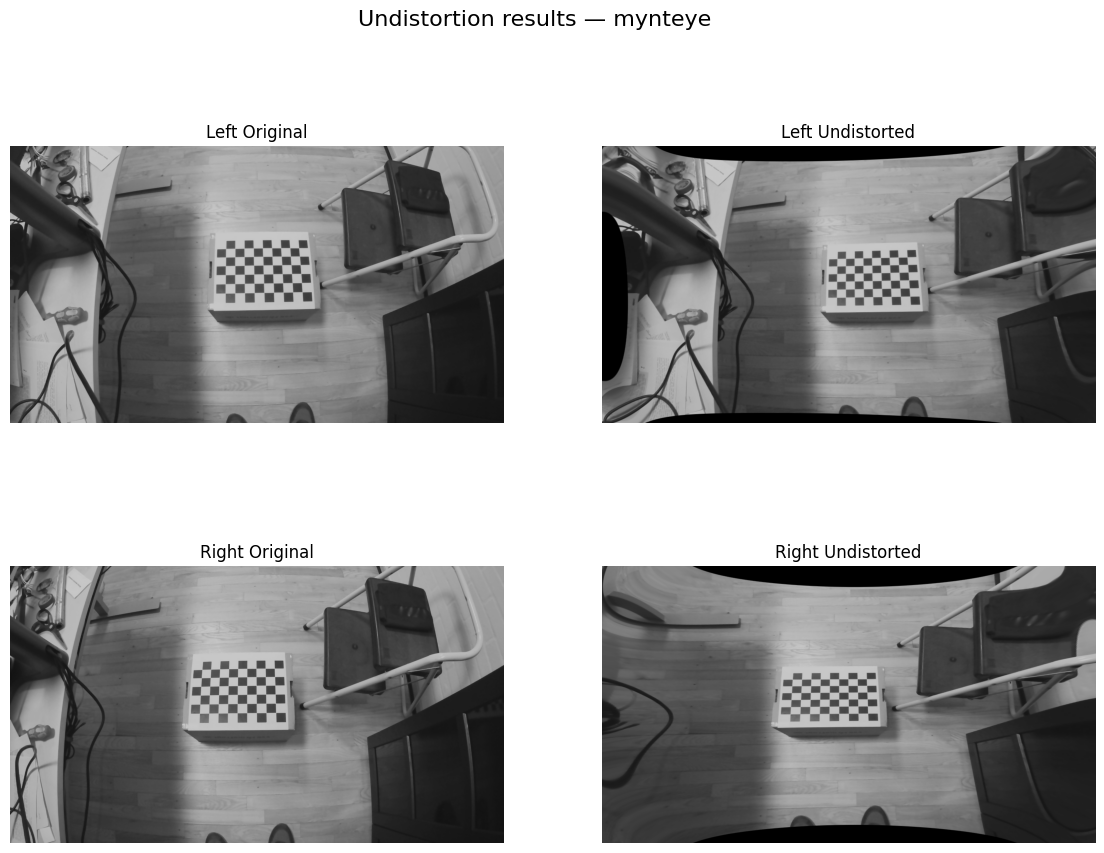

In [6]:
# === EX1-style: Monochrome camera calibration & undistortion (display only) ===
# Runs on both rs/ and mynteye/ without saving images

import numpy as np
import cv2
import glob
import matplotlib.pyplot as plt

# --- common chessboard settings ---
nb_vertical   = 7     # inner corners across
nb_horizontal = 6     # inner corners down
pattern_size  = (nb_vertical, nb_horizontal)
square_size_mm = 33.6 # physical square size (for stereo later, not needed here)

def calibrate_and_show(folder):
    print(f"\n=== Calibrating {folder} ===")
    left_imgs  = sorted(glob.glob(f'{folder}/left-*.png'))
    right_imgs = sorted(glob.glob(f'{folder}/right-*.png'))
    assert left_imgs and right_imgs, f"No left/right images found in {folder}"

    # object points template
    objp = np.zeros((nb_horizontal*nb_vertical,3), np.float32)
    objp[:,:2] = np.mgrid[0:nb_vertical,0:nb_horizontal].T.reshape(-1,2)

    objpoints_L, imgpoints_L = [], []
    objpoints_R, imgpoints_R = [], []

    # --- LEFT camera ---
    for fname in left_imgs:
        img = cv2.imread(fname)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        ret, corners = cv2.findChessboardCorners(
            gray, pattern_size,
            flags=cv2.CALIB_CB_ADAPTIVE_THRESH + cv2.CALIB_CB_NORMALIZE_IMAGE
        )
        if ret:
            corners = cv2.cornerSubPix(
                gray, corners, (11,11), (-1,-1),
                (cv2.TERM_CRITERIA_EPS+cv2.TERM_CRITERIA_MAX_ITER, 30, 1e-3)
            )
            objpoints_L.append(objp.copy())
            imgpoints_L.append(corners)

    # --- RIGHT camera ---
    for fname in right_imgs:
        img = cv2.imread(fname)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        ret, corners = cv2.findChessboardCorners(
            gray, pattern_size,
            flags=cv2.CALIB_CB_ADAPTIVE_THRESH + cv2.CALIB_CB_NORMALIZE_IMAGE
        )
        if ret:
            corners = cv2.cornerSubPix(
                gray, corners, (11,11), (-1,-1),
                (cv2.TERM_CRITERIA_EPS+cv2.TERM_CRITERIA_MAX_ITER, 30, 1e-3)
            )
            objpoints_R.append(objp.copy())
            imgpoints_R.append(corners)

    # --- Calibrate both sides ---
    grayL = cv2.cvtColor(cv2.imread(left_imgs[0]), cv2.COLOR_BGR2GRAY)
    grayR = cv2.cvtColor(cv2.imread(right_imgs[0]), cv2.COLOR_BGR2GRAY)
    retL, K_L, dist_L, rvecsL, tvecsL = cv2.calibrateCamera(objpoints_L, imgpoints_L, grayL.shape[::-1], None, None)
    retR, K_R, dist_R, rvecsR, tvecsR = cv2.calibrateCamera(objpoints_R, imgpoints_R, grayR.shape[::-1], None, None)
    print(f"[LEFT]  RMS: {retL:.4f}\nK_L:\n{K_L}\nDist_L:\n{dist_L.ravel()}")
    print(f"[RIGHT] RMS: {retR:.4f}\nK_R:\n{K_R}\nDist_R:\n{dist_R.ravel()}")

    # --- Undistort and show one sample pair ---
    sample_L, sample_R = left_imgs[0], right_imgs[0]
    imgL, imgR = cv2.imread(sample_L), cv2.imread(sample_R)
    h, w = imgL.shape[:2]
    newK_L, roi_L = cv2.getOptimalNewCameraMatrix(K_L, dist_L, (w,h), 1, (w,h))
    newK_R, roi_R = cv2.getOptimalNewCameraMatrix(K_R, dist_R, (w,h), 1, (w,h))
    undL = cv2.undistort(imgL, K_L, dist_L, None, newK_L)
    undR = cv2.undistort(imgR, K_R, dist_R, None, newK_R)

    # Display before/after for LEFT and RIGHT
    fig, ax = plt.subplots(2, 2, figsize=(14,10))
    ax[0,0].imshow(cv2.cvtColor(imgL, cv2.COLOR_BGR2RGB)); ax[0,0].set_title('Left Original')
    ax[0,1].imshow(cv2.cvtColor(undL, cv2.COLOR_BGR2RGB)); ax[0,1].set_title('Left Undistorted')
    ax[1,0].imshow(cv2.cvtColor(imgR, cv2.COLOR_BGR2RGB)); ax[1,0].set_title('Right Original')
    ax[1,1].imshow(cv2.cvtColor(undR, cv2.COLOR_BGR2RGB)); ax[1,1].set_title('Right Undistorted')
    for a in ax.ravel(): a.axis('off')
    plt.suptitle(f"Undistortion results — {os.path.basename(folder)}", fontsize=16)
    plt.show()

# --- Run for both datasets ---
calibrate_and_show('rs')
calibrate_and_show('mynteye')
